<a href="https://colab.research.google.com/github/nicolasengland14-gif/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment%201/Econ_5200_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
student_basket = [
    {'Item': 'Chick-Fil-A Spicy Delxue','Price_2016': 4.05,'Price_2026': 6.85},
    {'Item': 'Basic Netflix Subscription', 'Price_2016': 9.99,'Price_2026': 17.99},
    {'Item': 'Northeastern Total Costs', 'Price_2016': 65503,'Price_2026': 94137},
    {'Item': 'Honda Civic', 'Price_2016': 18640,'Price_2026':25745}
]

In [50]:
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2026'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Chick-Fil-A Spicy Delxue: 69.14% Inflation
Basic Netflix Subscription: 80.08% Inflation
Northeastern Total Costs: 43.71% Inflation
Honda Civic: 38.12% Inflation


In [51]:
!pip install fredapi
from fredapi import Fred
fred = Fred(api_key='82078b7e0f65bcf75cbf64afe01471d7')

official_cpi = fred.get_series('CPIAUCSL')
tuition = fred.get_series('CUSR0000SEEB')
food = fred.get_series('CUSR0000SEFV')
car = fred.get_series('CUSR0000SETA01')
streaming = fred.get_series('CUSR0000SERA02')


In [52]:
Food_index = (6.85 / 4.05) * 100
Streaming_Index = (17.99 / 9.99) * 100
Tuition_Index = (94137 / 65503) * 100
Car_Index = (25745 / 18640) * 100

In [53]:
df = pd.DataFrame({'Chick-Fil-A Spicy Deluxe': food, 'Basic Netflix Subscription':streaming, 'Northeastern Total Costs': tuition, 'Honda Civic':car, 'CPI': official_cpi})

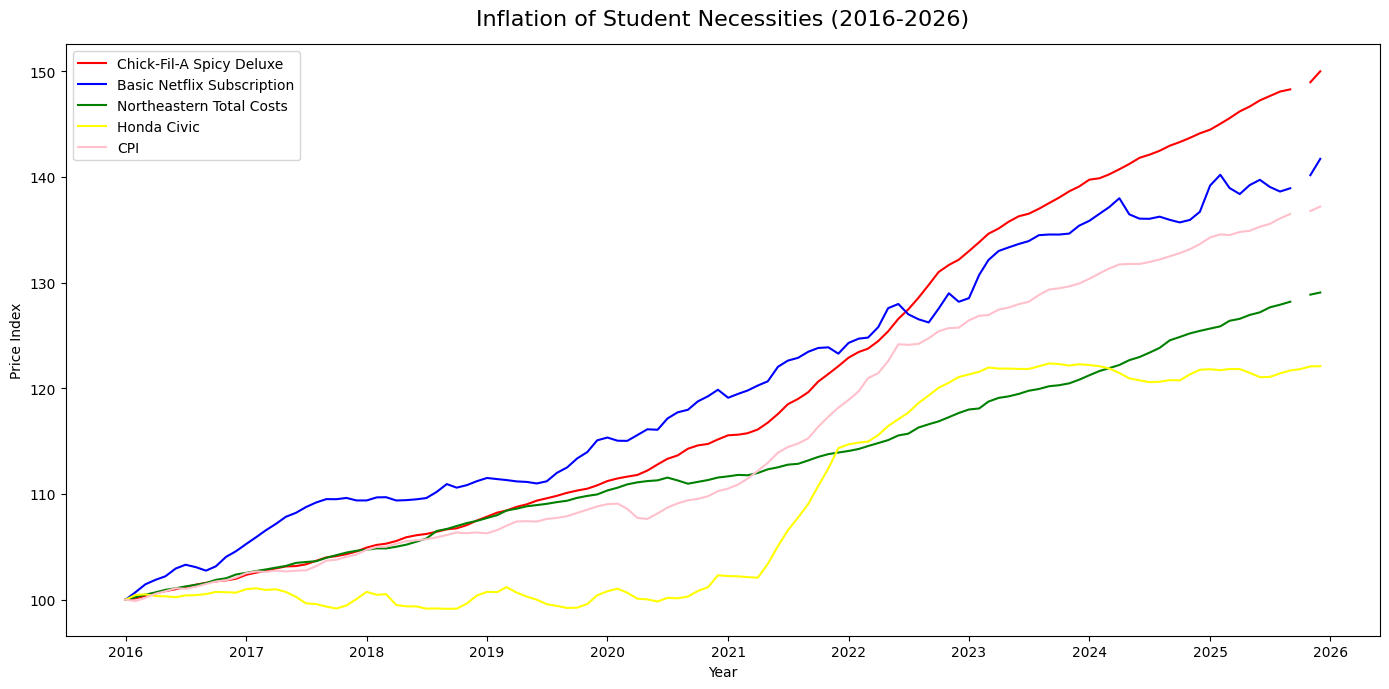

In [54]:
from matplotlib.lines import lineStyles

df = df.loc["2016":"2026"]
base_2016 = df.loc["2016"].iloc[0, :]
df_indexed = df / base_2016 * 100

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_indexed.index, df_indexed['Chick-Fil-A Spicy Deluxe'], linestyle='-', color='red', label='Chick-Fil-A Spicy Deluxe')
ax.plot(df_indexed.index, df_indexed['Basic Netflix Subscription'], linestyle='-',  color='blue', label='Basic Netflix Subscription')
ax.plot(df_indexed.index, df_indexed['Northeastern Total Costs'], linestyle='-', color= 'green', label='Northeastern Total Costs')
ax.plot(df_indexed.index, df_indexed['Honda Civic'], linestyle='-', color='yellow', label='Honda Civic')
ax.plot(df_indexed.index, df_indexed['CPI'], linestyle='-', color='pink', label='CPI')

ax.set_title('Inflation of Student Necessities (2016-2026)', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Price Index')

ax.legend()
plt.tight_layout()
plt.show()



In [55]:
#Tuition includes housing
student_SPI_weights = {
    'food': 0.05,
    'tuition': 0.65,
    'car': 0.25,
    'streaming': 0.05
}

official_CPI_weights = {
    'food': 0.21,
    'tuition': 0.44,
    'car': 0.30,
    'streaming': 0.05
}
col_map = {
    'food': 'Chick-Fil-A Spicy Deluxe',
    'streaming': 'Basic Netflix Subscription',
    'tuition': 'Northeastern Total Costs',
    'car': 'Honda Civic'
}

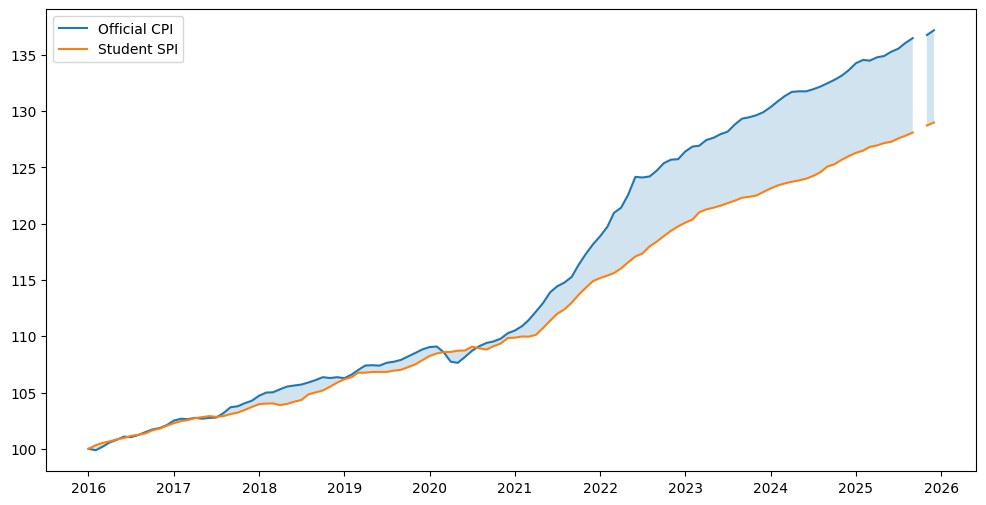

In [56]:
df_indexed["Student_SPI"] = (
    student_SPI_weights['food']      * df_indexed['Chick-Fil-A Spicy Deluxe'] +
    student_SPI_weights['tuition']   * df_indexed['Northeastern Total Costs'] +
    student_SPI_weights['car']       * df_indexed['Honda Civic'] +
    student_SPI_weights['streaming'] * df_indexed['Basic Netflix Subscription']
)
df_indexed["official_CPI_weights"] = (
    official_CPI_weights['food']      * df_indexed['Chick-Fil-A Spicy Deluxe'] +
    official_CPI_weights['tuition']   * df_indexed['Northeastern Total Costs'] +
    official_CPI_weights['car']       * df_indexed['Honda Civic'] +
    official_CPI_weights['streaming'] * df_indexed['Basic Netflix Subscription']
)
plt.figure(figsize=(12, 6))
plt.plot(df_indexed.index, df_indexed["CPI"], label="Official CPI")
plt.plot(df_indexed.index, df_indexed["Student_SPI"], label="Student SPI")
plt.fill_between(df_indexed.index, df_indexed["Student_SPI"], df_indexed["CPI"], alpha=0.2)
plt.legend()
plt.show()

In [57]:
df_RAW = pd.DataFrame({'CPI Tuition': tuition, 'CPI Streaming': streaming})

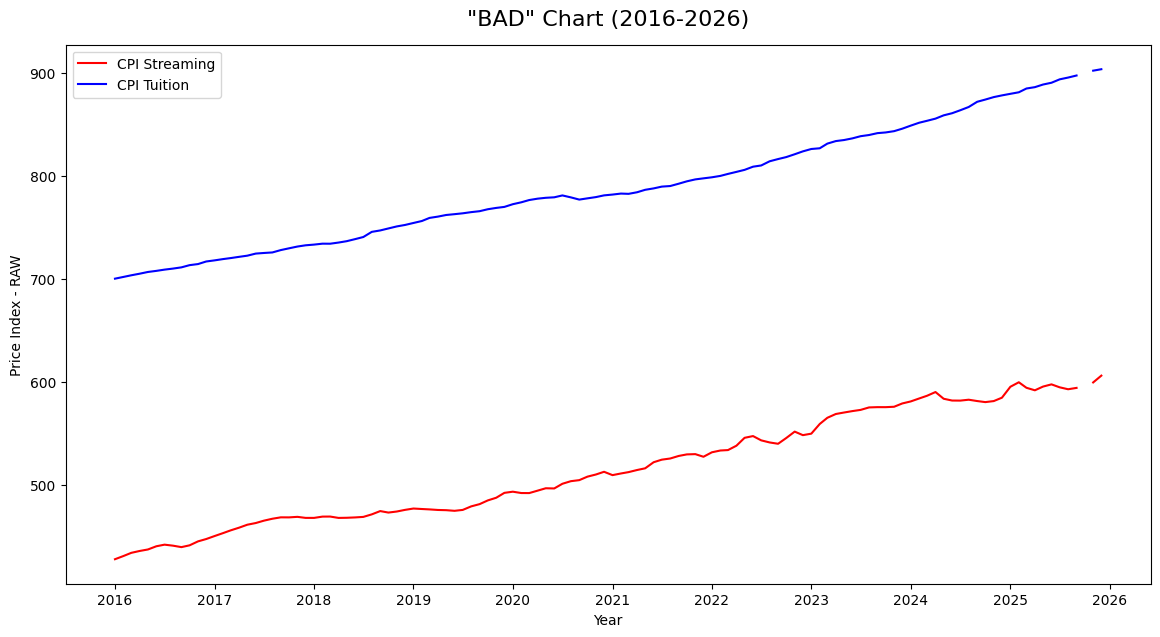

In [58]:
df_RAW = df_RAW.loc["2016":"2026"]

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df_RAW.index, df_RAW['CPI Streaming'], linestyle='-', color='red', label='CPI Streaming')
ax.plot(df_RAW.index, df_RAW['CPI Tuition'], linestyle='-', color='blue', label='CPI Tuition')
ax.set_title('"BAD" Chart (2016-2026)', fontsize=16, pad=14)
ax.set_xlabel('Year')
ax.set_ylabel('Price Index - RAW')

ax.legend()
plt.show()

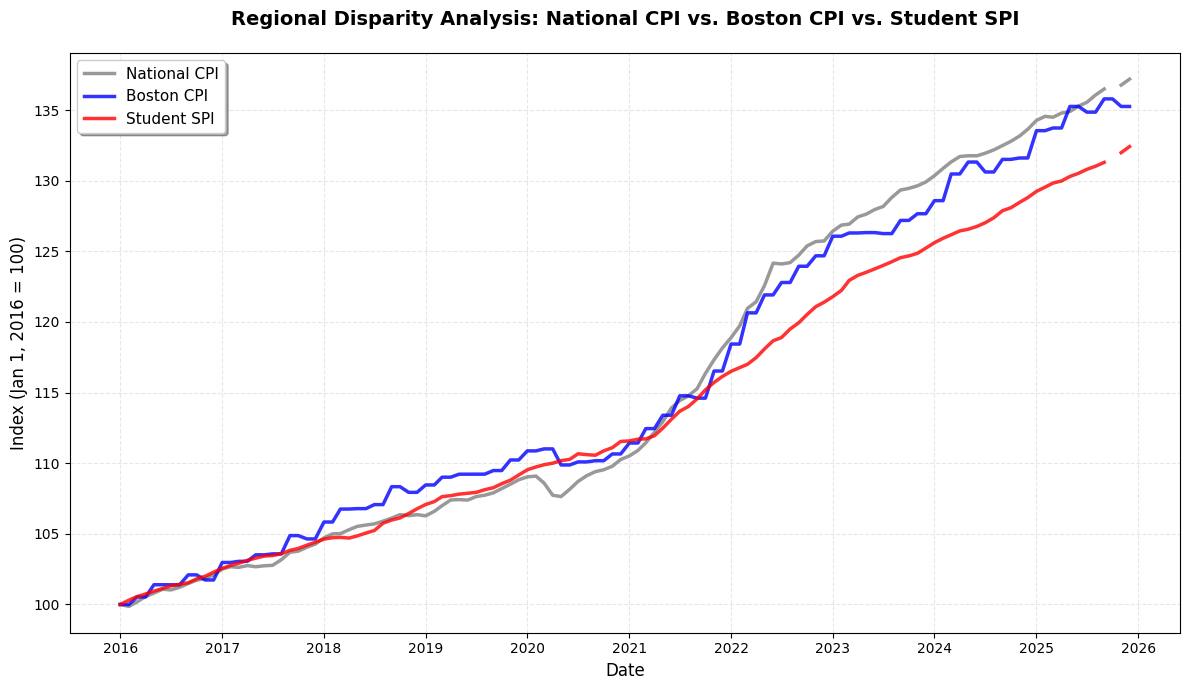


MACROECONOMIC DISPARITY ANALYSIS

Student SPI Composition:
  Northeastern Costs:     60%
  Chick-Fil-A:            15%
  Honda Civic:            15%
  Netflix Subscription:   10%

Latest Values (as of 2025-12-01):
  National CPI:   137.19
  Boston CPI:     135.25
  Student SPI:    132.41

Cumulative Change since Jan 2016:
  National CPI:   37.19%
  Boston CPI:     35.25%
  Student SPI:    32.41%

Regional & Demographic Disparities:
  Boston Regional Premium:   -1.93 points
  Student Burden Premium:    -4.77 points


In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a Student-Specific Price Index (SPI) from your existing student-relevant items
# Weighted average of student-relevant expenses
weights = {
    'Chick-Fil-A Spicy Deluxe': 0.15,      # Food
    'Basic Netflix Subscription': 0.10,     # Entertainment
    'Northeastern Total Costs': 0.60,       # Tuition/Housing (largest expense)
    'Honda Civic': 0.15                     # Transportation
}

# Calculate Student SPI as weighted average, normalized to Jan 2016 = 100
student_components = df[['Chick-Fil-A Spicy Deluxe', 'Basic Netflix Subscription',
                         'Northeastern Total Costs', 'Honda Civic']]

# Normalize each component to Jan 2016 = 100
baseline_date = '2016-01-01'
normalized_components = student_components / student_components.loc[baseline_date] * 100

# Calculate weighted average
df['Student_SPI'] = (
    normalized_components['Chick-Fil-A Spicy Deluxe'] * weights['Chick-Fil-A Spicy Deluxe'] +
    normalized_components['Basic Netflix Subscription'] * weights['Basic Netflix Subscription'] +
    normalized_components['Northeastern Total Costs'] * weights['Northeastern Total Costs'] +
    normalized_components['Honda Civic'] * weights['Honda Civic']
)

# Also normalize National CPI to Jan 2016 = 100 for comparison
df['National_CPI'] = (df['CPI'] / df.loc[baseline_date, 'CPI']) * 100

# Create the comparative plot
plt.figure(figsize=(12, 7))

# Plot all three series
plt.plot(df.index, df['National_CPI'], color='grey', linewidth=2.5,
         label='National CPI', alpha=0.8)
plt.plot(df.index, df['Boston_CPI'], color='blue', linewidth=2.5,
         label='Boston CPI', alpha=0.8)
plt.plot(df.index, df['Student_SPI'], color='red', linewidth=2.5,
         label='Student SPI', alpha=0.8)

# Formatting
plt.title('Regional Disparity Analysis: National CPI vs. Boston CPI vs. Student SPI',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Index (Jan 1, 2016 = 100)', fontsize=12)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()

# Summary statistics
print("\n" + "="*60)
print("MACROECONOMIC DISPARITY ANALYSIS")
print("="*60)
print(f"\nStudent SPI Composition:")
print(f"  Northeastern Costs:     {weights['Northeastern Total Costs']*100:.0f}%")
print(f"  Chick-Fil-A:            {weights['Chick-Fil-A Spicy Deluxe']*100:.0f}%")
print(f"  Honda Civic:            {weights['Honda Civic']*100:.0f}%")
print(f"  Netflix Subscription:   {weights['Basic Netflix Subscription']*100:.0f}%")

print(f"\nLatest Values (as of {df.index[-1].strftime('%Y-%m-%d')}):")
print(f"  National CPI:  {df['National_CPI'].iloc[-1]:>7.2f}")
print(f"  Boston CPI:    {df['Boston_CPI'].iloc[-1]:>7.2f}")
print(f"  Student SPI:   {df['Student_SPI'].iloc[-1]:>7.2f}")

print(f"\nCumulative Change since Jan 2016:")
print(f"  National CPI:  {(df['National_CPI'].iloc[-1] - 100):>6.2f}%")
print(f"  Boston CPI:    {(df['Boston_CPI'].iloc[-1] - 100):>6.2f}%")
print(f"  Student SPI:   {(df['Student_SPI'].iloc[-1] - 100):>6.2f}%")

# Calculate disparities
boston_premium = df['Boston_CPI'].iloc[-1] - df['National_CPI'].iloc[-1]
student_burden = df['Student_SPI'].iloc[-1] - df['National_CPI'].iloc[-1]

print(f"\nRegional & Demographic Disparities:")
print(f"  Boston Regional Premium:  {boston_premium:+6.2f} points")
print(f"  Student Burden Premium:   {student_burden:+6.2f} points")
print("="*60)